In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Lasso , Ridge 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.model_selection import KFold
from pathlib import Path
import os

In [2]:
IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE :
    DATA_DIR = Path('/kaggle/input/house-prices-advanced-regression-techniques')

else :
    # cwd() <> Current Working Directory , parent <> backward a folder , / <> join paths
    DATA_DIR = Path.cwd().parent / 'datasets' / 'processed'

data = pd.read_csv( DATA_DIR / 'final_train.csv')

print(f"data shape = {data.shape}")

data shape = (1458, 233)


In [3]:
X_train = data.drop( 'SalePrice' , axis= 1 )
y_train = data['SalePrice']

X_train.shape , y_train.shape

((1458, 232), (1458,))

In [4]:
models = {

'Linear_Regression' : LinearRegression() , 'lasso' : Lasso() ,
'ridge' : Ridge() , 'Decision_Tree_Regressor' : DecisionTreeRegressor(random_state=42), 
'Random_Forest_Regressor' : RandomForestRegressor(random_state=42) , 
'Gradient_Boosting_Regressor' : GradientBoostingRegressor(random_state=42),
'XGB_Regressor' : XGBRegressor(random_state=42 , objective='reg:squarederror') ,
'LGBM_Regressor' : LGBMRegressor(random_state=42),
'Cat_Boost_Regressor' : CatBoostRegressor(verbose=0 , random_state=42 )

          }

In [5]:
models_scores = {}
scores = {'r2_score' : 'r2' , 'RMSE' : 'neg_root_mean_squared_error'}
cv = KFold(  n_splits=5  , shuffle=True , random_state=42 )

for name_model , model in models.items():

    cv_results = cross_validate( model , X_train , y_train , cv= cv ,
                                 scoring= scores , return_train_score=True)

    models_scores[ name_model ] = {

        'CV_Train_R2_Score' : cv_results['train_r2_score'].mean() , 
        'CV_Test_R2_Score' : cv_results['test_r2_score'].mean() , 
        'CV_Train_RMSE' : - cv_results['train_RMSE'].mean() ,
        'CV_Test_RMSE' : - cv_results['test_RMSE'].mean() 

                                   }

    
models_scores_df = pd.DataFrame( models_scores ).T.sort_values(
                                by='CV_Test_RMSE' , ascending=True  )

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4631
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 173
[LightGBM] [Info] Start training from score 12.023362
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4633
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 174
[LightGBM] [Info] Start training from score 12.026498
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM]

In [6]:
models_scores_df

,CV_Train_R2_Score,CV_Test_R2_Score,CV_Train_RMSE,CV_Test_RMSE
Cat_Boost_Regressor,0.993773,0.919351,3.149087e-02,0.113038
ridge,0.946612,0.912958,9.230017e-02,0.117475
Gradient_Boosting_Regressor,0.966456,0.905243,7.316607e-02,0.122672
LGBM_Regressor,0.991477,0.899471,3.687722e-02,0.126256
Linear_Regression,0.947947,0.897408,9.113961e-02,0.127159
XGB_Regressor,0.999812,0.893176,5.448796e-03,0.129989
Random_Forest_Regressor,0.984262,0.888489,5.011328e-02,0.132782
lasso,0.851981,0.846668,1.536961e-01,0.156057
Decision_Tree_Regressor,1.000000,0.755799,5.095930e-17,0.196345


##### CV Test RMSE Comparison Across Models

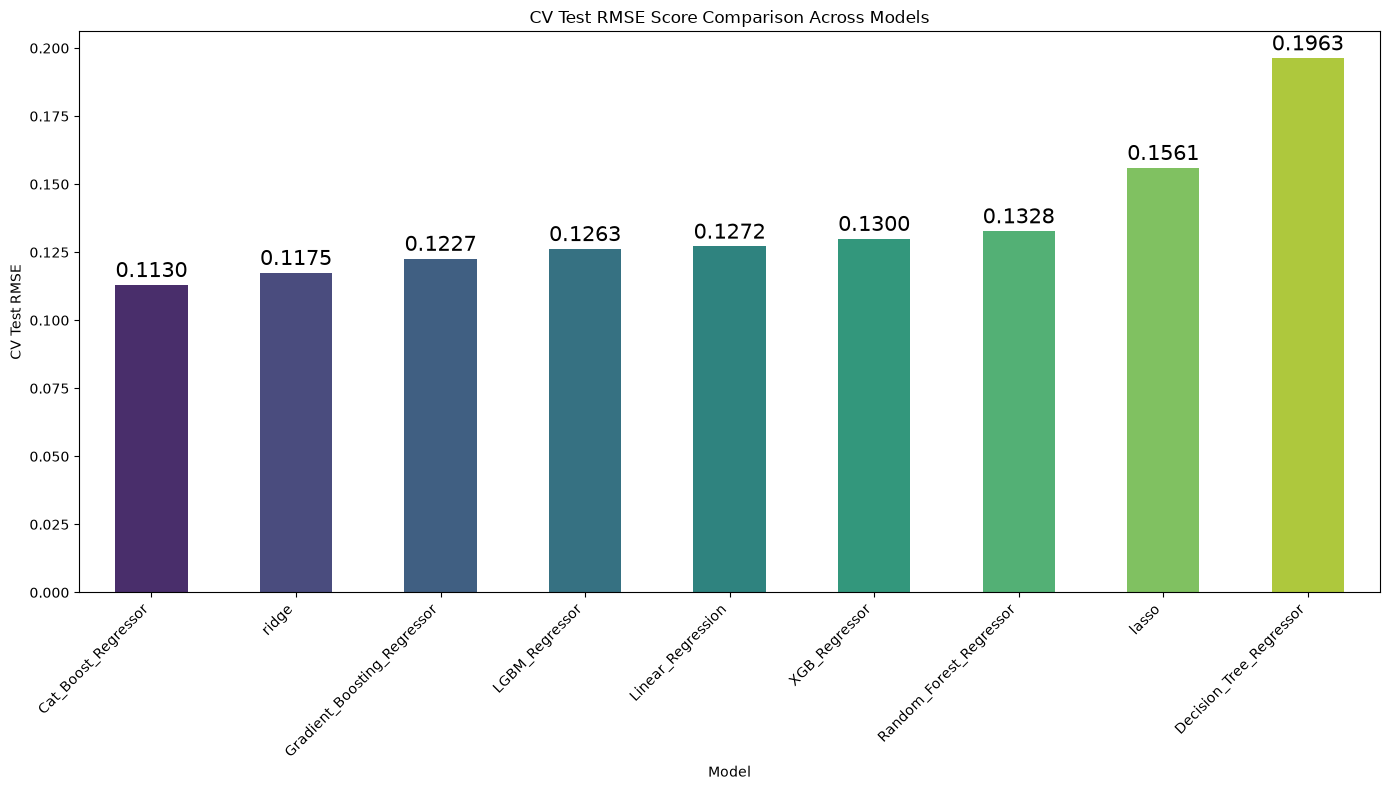

In [7]:

plt.figure( figsize=(14 , 8)) 
sns.barplot( x= models_scores_df.index , y= models_scores_df['CV_Test_RMSE'] , 
             palette='viridis',hue = models_scores_df.index , legend=False , width = 0.5
           )

for i , v in enumerate( models_scores_df['CV_Test_RMSE']) :
    plt.text( i , v + 0.001 , f'{v:.4f}', ha='center', va='bottom', fontsize=15)

plt.xlabel('Model')
plt.ylabel('CV Test RMSE')
plt.title('CV Test RMSE Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.tight_layout()
plt.show()

##### CV Test Comparison Across Models

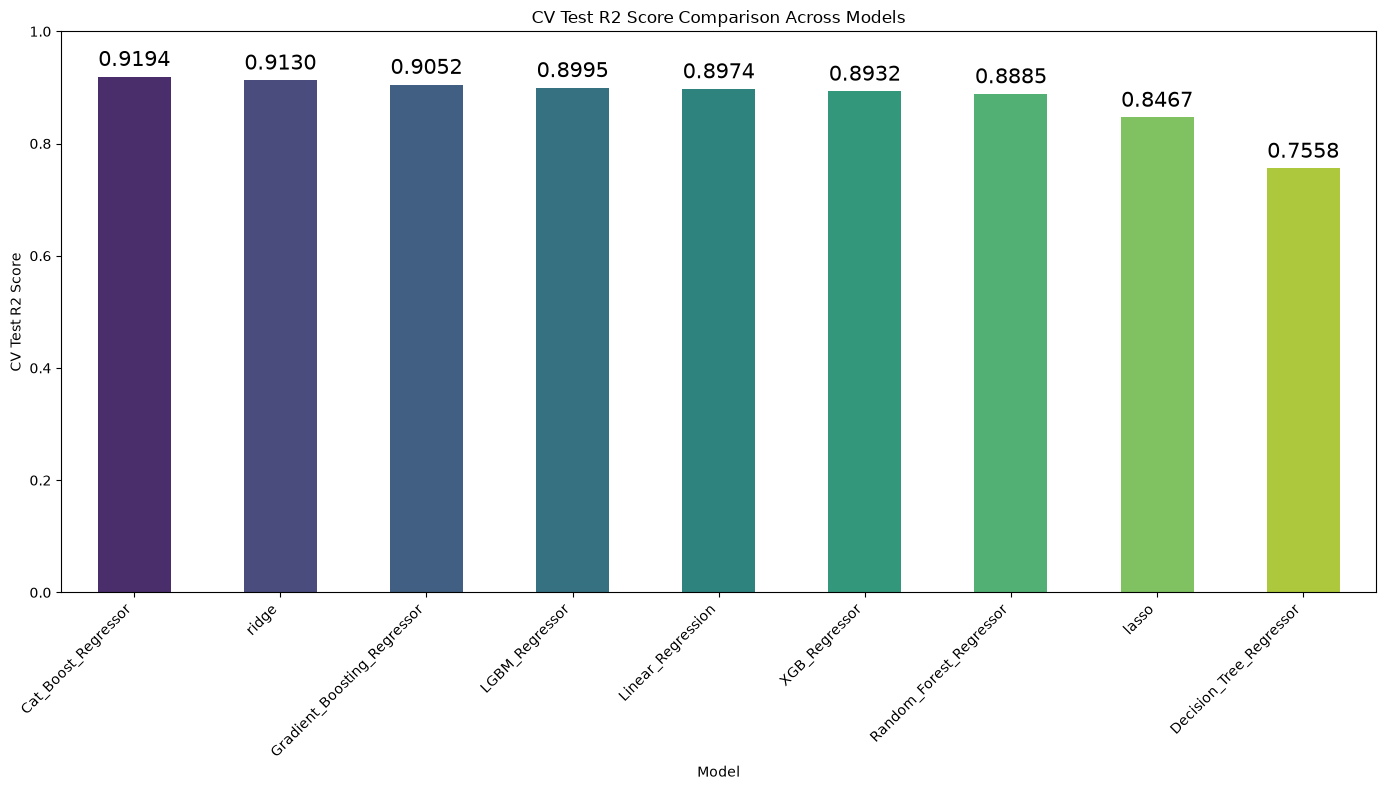

In [8]:
models_scores_df_sorted_test = models_scores_df.sort_values(
                             by='CV_Test_R2_Score' , ascending=False)

plt.figure( figsize=(14 , 8))
sns.barplot( x = models_scores_df_sorted_test.index ,
             y= models_scores_df_sorted_test['CV_Test_R2_Score'] , 
            palette='viridis',hue = models_scores_df_sorted_test.index ,
              legend=False , width = 0.5 
            )

for i , v in enumerate(models_scores_df_sorted_test['CV_Test_R2_Score']):
    plt.text(i , v + 0.01 , f'{v:.4f}', ha='center', va='bottom', fontsize=15 )

    
plt.xlabel('Model')
plt.ylabel('CV Test R2 Score')
plt.title('CV Test R2 Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.ylim(0 , 1)
plt.tight_layout()
plt.show()

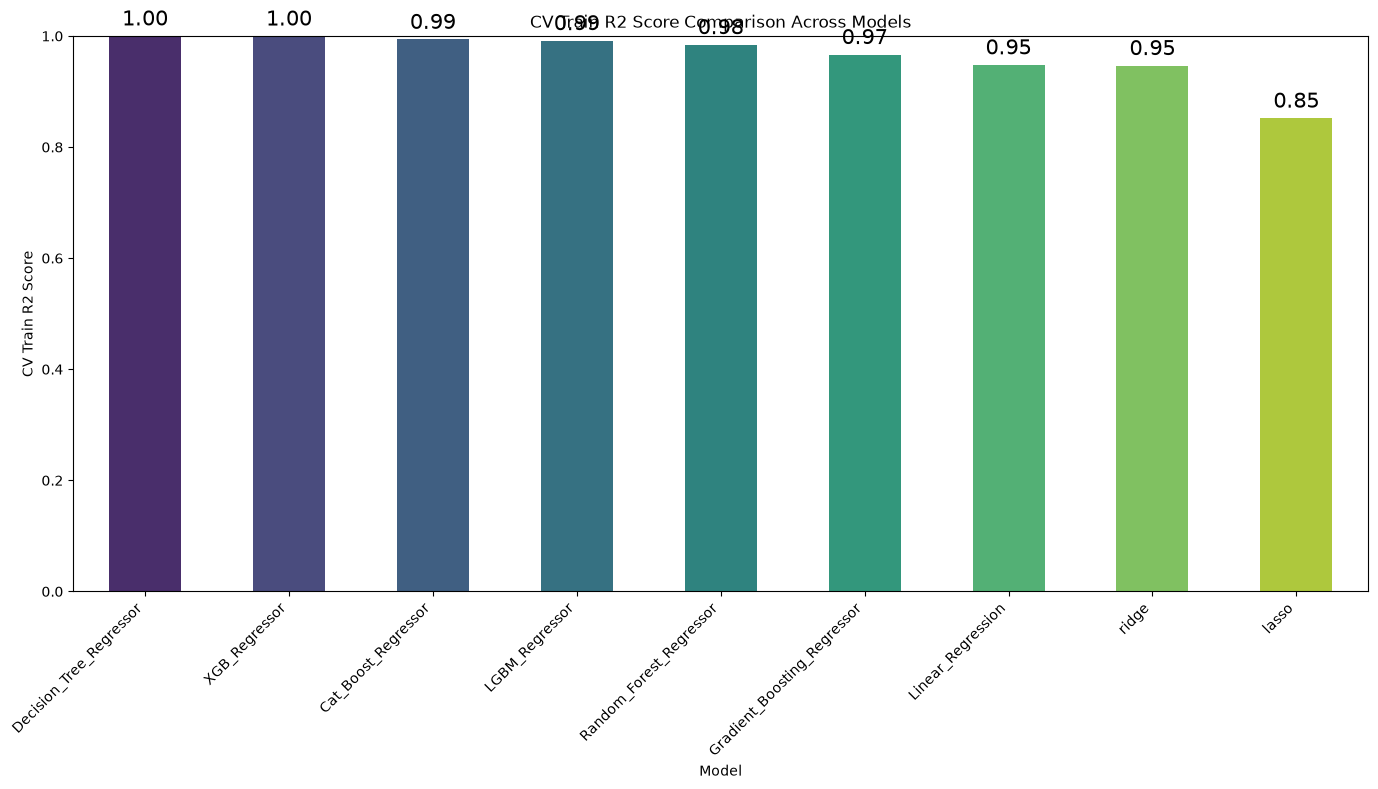

In [9]:
models_scores_df_sorted_test = models_scores_df.sort_values(
                             by='CV_Train_R2_Score' , ascending=False)

plt.figure( figsize=(14 , 8))
sns.barplot( x = models_scores_df_sorted_test.index ,
             y= models_scores_df_sorted_test['CV_Train_R2_Score'] , 
            palette='viridis',hue = models_scores_df_sorted_test.index ,
              legend=False , width = 0.5 
            )

for i , v in enumerate(models_scores_df_sorted_test['CV_Train_R2_Score']):
    plt.text(i , v + 0.01 , f'{v:.2f}', ha='center', va='bottom', fontsize=15 )

    
plt.xlabel('Model')
plt.ylabel('CV Train R2 Score')
plt.title('CV Train R2 Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.ylim(0 , 1)
plt.tight_layout()
plt.show()

#### We Will Take These models
- Cat_Boost_Regressor	
- ridge	
- Gradient_Boosting_Regressor	
- LGBM_Regressor	
- Linear_Regression	
- XGB_Regressor	
- Random_Forest_Regressoregressor	

In [10]:
CatBoostRegressor_model = CatBoostRegressor(verbose=0 , random_state= 42 )
Ridge_model = Ridge()
GradientBoostingRegressor_model = GradientBoostingRegressor( random_state= 42 )
LGBMRegressor_model = LGBMRegressor(random_state= 42)
LinearRegression_model = LinearRegression()
XGBRegressor_model = XGBRegressor(random_state= 42)
RandomForestRegressor_model = RandomForestRegressor( random_state= 42 )

best_models = {
    'Cat_Boost_Regressor' : CatBoostRegressor_model , 
    'ridge' : Ridge_model , 
    'Gradient_Boosting_Regressor' : GradientBoostingRegressor_model ,
    'LGBM_Regressor' : LGBMRegressor_model , 
    'Linear_Regression' : LinearRegression_model , 
    'XGB_Regressor' : XGBRegressor_model , 
    'Random_Forest_Regressor' : RandomForestRegressor_model
               }

In [11]:
best_params = {

    'Cat_Boost_Regressor': {
        'iterations': [500, 1000, 1500, 2000],
        'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
        'depth': [4, 6, 8, 10],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'bootstrap_type': ['Bernoulli'],
        'subsample': [0.66, 0.8, 1],
        'random_strength': [0, 1, 5, 10]
    },

    'ridge': {
        'alpha': [0.01, 0.1, 1, 5, 10, 50, 100, 200],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag'],
        'fit_intercept': [True, False]
    },

    'Gradient_Boosting_Regressor': {
        'n_estimators': [100, 200, 500, 800],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'max_depth': [2, 3, 4, 5],
        'subsample': [0.7, 0.8, 0.9, 1],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },

    'LGBM_Regressor': {
        'n_estimators': [100, 300, 500, 800, 1000],
        'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
        'max_depth': [-1, 3, 4, 6, 7, 10],
        'num_leaves': [15, 31, 50, 70, 100],
        'subsample': [0.7, 0.8, 0.9, 1],
        'colsample_bytree': [0.7, 0.8, 0.9, 1],
        'min_child_samples': [5, 10, 20, 30, 50],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [0, 0.01, 0.1, 1]
    },

    'Linear_Regression': {
        'fit_intercept': [True, False],
        'positive': [False, True]
    },

    'XGB_Regressor': {
        'n_estimators': [100, 300, 500, 800, 1000],
        'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1],
        'min_child_weight': [1, 3, 5, 7],
        'gamma': [0, 0.01, 0.1, 0.3, 0.5],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [1, 3, 5, 10]
    },

    'Random_Forest_Regressor': {
        'n_estimators': [100, 300, 500, 800, 1000],
        'max_depth': [5, 10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }

}

In [ ]:
fitted_models = {}

for name_model , model in best_models.items():

    Random_GridSearchCV_model = RandomizedSearchCV( 
        model , best_params[name_model] , cv= cv , n_iter= 220 , 
        n_jobs= -1 , scoring = 'neg_root_mean_squared_error' ,
          return_train_score=True , random_state=42
                                                   )

    Random_GridSearchCV_model.fit( X_train , y_train )
 
    fitted_models[name_model] = Random_GridSearchCV_model

    print(f'\n{name_model} - Best RMSE = { - Random_GridSearchCV_model.best_score_}')
    print(f'{name_model} - Best params = { Random_GridSearchCV_model.best_params_}\n{"-" *50}\n')
    

In [ ]:
best_CatBoostRegressor_model = fitted_models['Cat_Boost_Regressor'].best_estimator_

best_GradientBoostingRegressor_model = fitted_models['Gradient_Boosting_Regressor'].best_estimator_

best_XGBRegressor_model = fitted_models['XGB_Regressor'].best_estimator_

best_LGBMRegressor_model = fitted_models['LGBM_Regressor'].best_estimator_

best_RandomForestRegressor_model = fitted_models['Random_Forest_Regressor'].best_estimator_

best_Ridge_model = fitted_models['ridge'].best_estimator_

best_LinearRegression_model = fitted_models['Linear_Regression'].best_estimator_


In [ ]:
import joblib
from pathlib import Path

MODELS_DIR = Path.cwd().parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

trained_models = {
    'Cat_Boost_Regressor': best_CatBoostRegressor_model,
    'Gradient_Boosting_Regressor': best_GradientBoostingRegressor_model,
    'XGB_Regressor': best_XGBRegressor_model,
    'LGBM_Regressor': best_LGBMRegressor_model,
    'Random_Forest_Regressor': best_RandomForestRegressor_model ,
    'ridge' : best_Ridge_model , 
    'Linear_Regression' : best_LinearRegression_model
                 }

for name, model in trained_models.items():
    joblib.dump(model, MODELS_DIR / f'{name}_model.pkl')
    print(f'Saved: {name}_model.pkl')

Saved: Cat_Boost_Regressor_model.pkl
Saved: Gradient_Boosting_Regressor_model.pkl
Saved: XGB_Regressor_model.pkl
Saved: LGBM_Regressor_model.pkl
Saved: Random_Forest_Regressor_model.pkl
Saved: ridge_model.pkl
Saved: Linear_Regression_model.pkl
